In [ ]:
# Cài đặt pyodbc nếu chưa có
!pip install pyodbc

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

In [ ]:
# Block 1: Imports và thiết lập thiết bị
import os
import zipfile
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import models, transforms
from torchvision.models import ResNet50_Weights
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import json
import sys
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

# Thiết lập thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sử dụng thiết bị: {device}")


Mounted at /content/drive
Sử dụng thiết bị: cuda


In [ ]:
# Cell 2: Cấu hình Adam Optimizer
# Phát hiện GPU và đề xuất batch_size
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'
print(f"Device: {device}, GPU: {gpu_name}")

# === CẤU HÌNH ADAM OPTIMIZER ===
OPTIMIZER_NAME = 'Adam'  # Tên optimizer để phân biệt

# Hyperparameters chung cho cả 3 models
BATCH_SIZE = 32          # Colab GPU T4/P100: 16-32, V100/A100: 32-64
NUM_EPOCHS = 20          # Transfer learning (freeze backbone): 10-20
PATIENCE = 6             # Early stopping patience

# Adam Learning rates
ADAM_LR = 1e-3           # ResNet50, MobileNetV2
ADAM_LR_EFFICIENTNET = 5e-4  # EfficientNet-B0 (nhạy cảm hơn)
ADAM_WEIGHT_DECAY = 1e-4     # Weight decay (L2 regularization)

USE_AMP = torch.cuda.is_available()  # Bật mixed precision nếu có GPU

# Đường dẫn Google Drive (riêng cho Adam)
DRIVE_BASE = '/content/drive/MyDrive/plant_disease_adam'
MODELS_DIR = f'{DRIVE_BASE}/models'
PLOTS_DIR = f'{DRIVE_BASE}/plots'
CHECKPOINTS_DIR = f'{DRIVE_BASE}/checkpoints'

print(f"\n=== CẤU HÌNH ADAM ====")
print(f"Optimizer: {OPTIMIZER_NAME}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Num Epochs: {NUM_EPOCHS}")
print(f"Patience: {PATIENCE}")
print(f"Adam Learning Rate: {ADAM_LR}")
print(f"Adam EfficientNet LR: {ADAM_LR_EFFICIENTNET}")
print(f"Adam Weight Decay: {ADAM_WEIGHT_DECAY}")
print(f"Use AMP: {USE_AMP}")
print(f"Base Dir: {DRIVE_BASE}")


In [ ]:
# Cell 3: Giải nén file ZIP và tạo cấu trúc thư mục
# Dùng chung file ZIP từ thư mục data
zip_path = '/content/drive/MyDrive/data/plant_images.zip'
extract_path = '/content/'

os.makedirs(extract_path, exist_ok=True)
print("Đang giải nén file ZIP...")
start_time = time.time()

if not os.path.exists(zip_path):
    print(f"Lỗi: Không tìm thấy file ZIP tại {zip_path}. Vui lòng kiểm tra đường dẫn.")
    sys.exit()
else:
    try:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        extract_time = time.time() - start_time
        print(f"Thời gian giải nén: {extract_time:.2f} giây")

        def count_files_in_directory(directory):
            total_files = 0
            for root, dirs, files in os.walk(directory):
                total_files += len(files)
            return total_files

        plant_images_dir = os.path.join(extract_path, 'plant_images')
        if os.path.exists(plant_images_dir):
            total_files = count_files_in_directory(plant_images_dir)
            print(f"Tổng số file đã giải nén trong thư mục plant_images: {total_files}")
        else:
            print("Thư mục plant_images không tồn tại sau khi giải nén!")
            sys.exit()

        print("Cấu trúc thư mục sau khi giải nén:")
        for root, dirs, files in os.walk(plant_images_dir):
            level = root.replace(extract_path, '').count('/')
            indent = ' ' * 4 * level
            print(f"{indent}{os.path.basename(root)}/")
            for file in files[:3]:
                print(f"{indent}    {file}")
    except zipfile.BadZipFile:
        print(f"Lỗi: File zip tại {zip_path} bị hỏng.")
        sys.exit()
    except Exception as e:
        print(f"Đã xảy ra lỗi khi giải nén: {e}")
        sys.exit()

# Tạo thư mục models cho ResNet50, MobileNetV2, EfficientNet-B0 (dùng biến cấu hình)
for model_type in ['resnet50', 'mobilenetv2', 'efficientnetb0']:
    os.makedirs(f'{MODELS_DIR}/{model_type}/best', exist_ok=True)
    os.makedirs(f'{MODELS_DIR}/{model_type}/final', exist_ok=True)
    os.makedirs(f'{CHECKPOINTS_DIR}/{model_type}', exist_ok=True)

os.makedirs(PLOTS_DIR, exist_ok=True)
print("\n✓ Đã tạo cấu trúc thư mục cho 3 models")


Đang giải nén file ZIP...
Thời gian giải nén: 46.22 giây
Tổng số file đã giải nén trong thư mục plant_images: 88888
Cấu trúc thư mục sau khi giải nén:
plant_images/
    images/
        valid/
            Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot/
                97b35ced-b7ca-4f6d-8c22-5390c3d192c8___RS_GLSp 7307_270deg.JPG
                acbed711-885d-4f1d-986f-1fdf9b48cba5___RS_GLSp 7338_270deg.JPG
                ef4b7259-5826-4036-9316-e075afa2c200___RS_GLSp 4599 copy_new30degFlipLR.jpg
            Potato___healthy/
                799b10e8-ba67-4e08-9abe-748789572ad1___RS_HL 1881_new200degFlipLR.JPG
                14484ea5-9c34-427c-abe4-2743265aced0___RS_HL 4204_flipTB.JPG
                144d2475-21ab-4bdc-a67c-9672a9b711e6___RS_HL 5376_newGGR.JPG
            Squash___Powdery_mildew/
                eab3d3d5-4a30-4e80-b0f9-194a6e694fd9___UMD_Powd.M 0185.JPG
                c9de0902-a4a9-49d1-9a40-f2d65284ccee___MD_Powd.M 0150 copy.jpg
                6e9024d1-bb9e-42b

In [ ]:
# Cell 4: Đọc dữ liệu từ CSV (dùng CSV chung từ thư mục data)
media_root = '/content/'  # Thư mục chứa ảnh sau giải nén
csv_path = '/content/drive/MyDrive/data/plant_data.csv'  # CSV chung cho cả 2 notebooks

try:
    df = pd.read_csv(csv_path)
    print("Đã tải dữ liệu từ CSV")
    print(f"Tổng số ảnh: {len(df)}")
except Exception as e:
    print(f"Lỗi khi đọc CSV: {e}")
    sys.exit()

Đã tải dữ liệu từ CSV
Tổng số ảnh: 87867


In [ ]:
# Block 5: Chuẩn hóa dữ liệu và ánh xạ plant_type (loại bỏ cây chỉ có 1 class)
if df.empty:
    print("Lỗi: DataFrame rỗng. Kiểm tra file CSV.")
    sys.exit()
# Chuẩn hóa cột disease: loại bỏ khoảng cách thừa và chuyển thành title case
df['disease'] = df['disease'].apply(lambda x: x.strip().title() if pd.notnull(x) else 'Unknown')

# Ánh xạ plant_type - loại bỏ Blueberry, Orange, Raspberry, Soybean, Squash
PLANT_TYPE_MAPPING = {
    "Cherry": "Cherry",
    "Corn": "Corn",
    "Pepper": "Pepper",
    "Apple": "Apple",
    "Grape": "Grape",
    "Peach": "Peach",
    "Potato": "Potato",
    "Strawberry": "Strawberry",
    "Tomato": "Tomato",
    # Loại bỏ: "Blueberry", "Orange", "Raspberry", "Soybean", "Squash"
}
df['plant_type'] = df['plant_type'].map(PLANT_TYPE_MAPPING).fillna('Unknown')

# Loại bỏ các hàng có plant_type là 'Unknown' (Blueberry, Orange, Raspberry, Soybean, Squash)
unknown_plant_count = df['plant_type'].eq('Unknown').sum()
if unknown_plant_count > 0:
    print(f"Loại bỏ {unknown_plant_count} hàng có plant_type không hợp lệ (Blueberry, Orange, Raspberry, Soybean, Squash).")
    df = df[df['plant_type'] != 'Unknown']

# Kiểm tra disease không hợp lệ
invalid_disease_count = df['disease'].eq('Unknown').sum()
if invalid_disease_count > 0:
    print(f"Cảnh báo: Tìm thấy {invalid_disease_count} hàng có disease không hợp lệ (gán thành 'Unknown').")
    print("Các hàng không hợp lệ (mẫu):")
    print(df[df['disease'] == 'Unknown'][['image', 'plant_type', 'disease', 'dataset_type']].head(5))

print("Plant types sau ánh xạ:", df['plant_type'].unique())
print("Diseases sau xử lý:", df['disease'].unique())

Plant types sau ánh xạ: ['Apple' 'Blueberry' 'Cherry' 'Corn' 'Grape' 'Orange' 'Peach' 'Pepper'
 'Potato' 'Raspberry' 'Soybean' 'Squash' 'Strawberry' 'Tomato']
Diseases sau xử lý: ['Apple Scab' 'Black Rot' 'Cedar Apple Rust' 'Healthy' 'Powdery Mildew'
 'Cercospora Leaf Spot Gray Leaf Spot' 'Common Rust'
 'Northern Leaf Blight' 'Esca (Black Measles)'
 'Leaf Blight (Isariopsis Leaf Spot)' 'Haunglongbing (Citrus Greening)'
 'Bacterial Spot' 'Early Blight' 'Late Blight' 'Leaf Scorch' 'Leaf Mold'
 'Septoria Leaf Spot' 'Spider Mites Two-Spotted Spider Mite' 'Target Spot'
 'Tomato Mosaic Virus' 'Tomato Yellow Leaf Curl Virus']


In [ ]:
# Cell 6: Định nghĩa nhóm bệnh theo cây và lưu group_classes.json (đã loại bỏ cây chỉ có 1 class)
# Loại bỏ: Blueberry, Orange, Raspberry, Soybean, Squash
GROUPS = {
    "Apple": ["Apple Scab", "Black Rot", "Cedar Apple Rust", "Healthy"],
    "Tomato": ["Bacterial Spot", "Early Blight", "Healthy", "Late Blight",
               "Leaf Mold", "Septoria Leaf Spot", "Spider Mites Two-Spotted Spider Mite",
               "Target Spot", "Tomato Mosaic Virus", "Tomato Yellow Leaf Curl Virus"],
    "Potato": ["Early Blight", "Healthy", "Late Blight"],
    "Corn": ["Cercospora Leaf Spot Gray Leaf Spot", "Common Rust", "Healthy", "Northern Leaf Blight"],
    "Grape": ["Black Rot", "Esca (Black Measles)", "Healthy", "Leaf Blight (Isariopsis Leaf Spot)"],
    "Cherry": ["Healthy", "Powdery Mildew"],
    "Peach": ["Bacterial Spot", "Healthy"],
    "Pepper": ["Bacterial Spot", "Healthy"],
    "Strawberry": ["Healthy", "Leaf Scorch"]
}

# Lưu vào Google Drive (dùng biến cấu hình)
group_classes_path = f'{DRIVE_BASE}/group_classes.json'
with open(group_classes_path, 'w', encoding='utf-8') as f:
    json.dump(GROUPS, f, ensure_ascii=False)
print(f"Đã lưu group_classes.json tại: {group_classes_path}")
print(f"Tổng số plant types: {len(GROUPS)}")

Đã lưu group_classes.json


In [ ]:
# Block 7: Định nghĩa PlantDiseaseDataset class
class PlantDiseaseDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        self.valid_indices = []

        print(f"Đang kiểm tra {len(image_paths)} ảnh...")
        start_time = time.time()
        for idx, img_path in tqdm(enumerate(image_paths), total=len(image_paths), desc="Kiểm tra ảnh"):
            try:
                with Image.open(img_path) as img:
                    img.verify()
                self.valid_indices.append(idx)
            except Exception as e:
                print(f"Lỗi khi mở ảnh {img_path}: {e}")
        print(f"Thời gian kiểm tra ảnh: {time.time() - start_time:.2f} giây")
        print(f"Số ảnh hợp lệ: {len(self.valid_indices)}/{len(image_paths)}")

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        true_idx = self.valid_indices[idx]
        img_path = self.image_paths[true_idx]
        label = self.labels[true_idx]

        try:
            image = Image.open(img_path).convert('RGB')
        except Exception as e:
            print(f"Lỗi khi mở ảnh {img_path}: {e}")
            raise RuntimeError(f"Không thể mở ảnh {img_path}.")

        if self.transform:
            try:
                image = self.transform(image)
            except Exception as e:
                print(f"Lỗi khi biến đổi ảnh {img_path}: {e}")
                raise RuntimeError(f"Không thể biến đổi ảnh {img_path}.")

        return image, label



In [ ]:
# Block 8: Data transforms (tối ưu cho từng model)
# ResNet50 và MobileNetV2: 224x224
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# EfficientNet-B0: 224x224 trực tiếp (không qua resize 256)
efficientnet_transforms = {
    'train': transforms.Compose([
        transforms.Resize(224),  # Resize trực tiếp về 224
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),  # Thêm augmentation
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(224),  # Resize trực tiếp về 224
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}


In [ ]:
# Block 9: Hàm lưu và tải checkpoint
def save_checkpoint(model, optimizer, epoch, train_losses, val_losses, train_accs, val_accs, checkpoint_path, plant_type):
    checkpoint = {
        'epoch': epoch + 1,  # Lưu epoch tiếp theo
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accs': train_accs,
        'val_accs': val_accs,
        'plant_type': plant_type
    }
    try:
        torch.save(checkpoint, checkpoint_path)
        print(f"Đã lưu checkpoint cho {plant_type} tại epoch {epoch+1} vào {checkpoint_path}")
    except Exception as e:
        print(f"Lỗi khi lưu checkpoint cho {plant_type} vào {checkpoint_path}: {e}")

def load_checkpoint(model, optimizer, checkpoint_path, device):
    if os.path.exists(checkpoint_path):
        try:
            checkpoint = torch.load(checkpoint_path, map_location=device)
            model.load_state_dict(checkpoint['model_state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
            epoch = checkpoint['epoch']
            train_losses = checkpoint['train_losses']
            val_losses = checkpoint['val_losses']
            train_accs = checkpoint['train_accs']
            val_accs = checkpoint['val_accs']
            print(f"Đã tải checkpoint từ {checkpoint_path} tại epoch {epoch}")
            return epoch, train_losses, val_losses, train_accs, val_accs
        except Exception as e:
            print(f"Lỗi khi tải checkpoint từ {checkpoint_path}: {e}. Huấn luyện từ đầu.")
            return 0, [], [], [], []
    return 0, [], [], [], []



In [ ]:
# Cell 10: Hàm train_model (giữ progress bar, bỏ thông báo dài)
def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs, patience, device,
                model_path, best_model_path, checkpoint_path, plant_type, model_name, verbose=1):
    """
    Huấn luyện model với checkpoint support và progress bar.
    
    Checkpoint lưu progress sau mỗi epoch để resume nếu bị gián đoạn (Colab timeout, crash).
    """
    model = model.to(device)
    
    # Tải checkpoint nếu có (resume training)
    start_epoch, train_losses, val_losses, train_accs, val_accs = load_checkpoint(model, optimizer, checkpoint_path, device)
    best_val_acc = float('-inf') if not val_accs else max(val_accs)
    epochs_no_improve = 0
    start_time = time.time()

    for epoch in range(start_epoch, num_epochs):
        # Train
        model.train()
        running_loss, running_corrects, total_samples = 0.0, 0, 0
        
        for inputs, labels in tqdm(train_loader, desc=f"Huấn luyện {plant_type} (Epoch {epoch+1})", ncols=100, file=sys.stdout):
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            running_corrects += torch.sum(preds == labels.data)
            total_samples += inputs.size(0)
        
        train_loss = running_loss / total_samples
        train_acc = (running_corrects.double() / total_samples).item()
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        print(f"Huấn luyện {plant_type} - Loss: {train_loss:.6f} Acc: {train_acc:.4f}")
        
        # Validation
        model.eval()
        running_loss, running_corrects, total_samples = 0.0, 0, 0
        
        with torch.no_grad():
            for inputs, labels in tqdm(val_loader, desc=f"Kiểm tra {plant_type} (Epoch {epoch+1})", ncols=100, file=sys.stdout):
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                running_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                running_corrects += torch.sum(preds == labels.data)
                total_samples += inputs.size(0)
        
        val_loss = running_loss / total_samples
        val_acc = (running_corrects.double() / total_samples).item()
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        print(f"Kiểm tra {plant_type} - Loss: {val_loss:.6f} Acc: {val_acc:.4f}")
        
        # Save checkpoint (silent)
        save_checkpoint(model, optimizer, epoch, train_losses, val_losses, train_accs, val_accs, checkpoint_path, plant_type)
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f"✓ Best: {best_val_acc:.4f}")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"⏹ Early stop")
                break
    
    # Save final model
    torch.save(model.state_dict(), model_path)
    
    # Save plot (silent)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train', color='blue')
    plt.plot(val_losses, label='Val', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f'Loss - {plant_type}')
    
    plt.subplot(1, 2, 2)
    plt.plot(train_accs, label='Train', color='blue')
    plt.plot(val_accs, label='Val', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f'Accuracy - {plant_type}')
    plt.tight_layout()
    
    model_plots_dir = f'{PLOTS_DIR}/{model_name}'
    os.makedirs(model_plots_dir, exist_ok=True)
    plot_path = f'{model_plots_dir}/{plant_type.lower()}_training_plot.png'
    plt.savefig(plot_path)
    plt.close()
    
    print(f"\n✓ {plant_type} hoàn tất ({(time.time() - start_time)/60:.1f} phút)\n")
    
    return model, {'train_losses': train_losses, 'val_losses': val_losses, 'train_accs': train_accs, 'val_accs': val_accs}


=== Xử lý Apple ===
Số ảnh train (Apple): 7771
Số ảnh validation (Apple): 1943
Số lớp bệnh cho Apple: 4
Đang kiểm tra 7771 ảnh...


Kiểm tra ảnh: 100%|██████████| 7771/7771 [00:00<00:00, 11161.31it/s]


Thời gian kiểm tra ảnh: 0.70 giây
Số ảnh hợp lệ: 7771/7771
Đang kiểm tra 1943 ảnh...


Kiểm tra ảnh: 100%|██████████| 1943/1943 [00:00<00:00, 18031.26it/s]


Thời gian kiểm tra ảnh: 0.11 giây
Số ảnh hợp lệ: 1943/1943
Số batch train (Apple): 971
Số batch validation (Apple): 242
Mô hình cho Apple đã được khởi tạo với 4 lớp
Đã tải checkpoint từ /content/drive/MyDrive/plant_disease/checkpoints/apple_checkpoint.pth tại epoch 10
Thời gian huấn luyện tổng cộng (Apple): 0.00 phút
Lưu mô hình cuối cùng cho Apple vào /content/drive/MyDrive/plant_disease/models/final/apple_model.pth
Huấn luyện hoàn tất cho Apple. Mô hình cuối cùng lưu tại: /content/drive/MyDrive/plant_disease/models/final/apple_model.pth
Mô hình tốt nhất lưu tại: /content/drive/MyDrive/plant_disease/models/best/apple_model.pth

=== Xử lý Tomato ===
Số ảnh train (Tomato): 18345
Số ảnh validation (Tomato): 4585
Số lớp bệnh cho Tomato: 10
Đang kiểm tra 18345 ảnh...


...

Kiểm tra Strawberry - Loss: 0.007063 Acc: 1.0000
Đã lưu checkpoint cho Strawberry tại epoch 6 vào /content/drive/MyDrive/plant_disease/checkpoints/strawberry_checkpoint.pth
Thời gian epoch 6 (Strawberry): 0.24 phút

Epoch 7/10 for Strawberry
----------


Huấn luyện Strawberry (Epoch 7): 100%|██████████| 449/449 [00:12<00:00, 36.35it/s]


Huấn luyện Strawberry - Loss: 0.089329 Acc: 0.9666


Kiểm tra Strawberry (Epoch 7): 100%|██████████| 112/112 [00:01<00:00, 56.16it/s]


Kiểm tra Strawberry - Loss: 0.003634 Acc: 1.0000
Đã lưu checkpoint cho Strawberry tại epoch 7 vào /content/drive/MyDrive/plant_disease/checkpoints/strawberry_checkpoint.pth
Thời gian epoch 7 (Strawberry): 0.24 phút
Dừng sớm tại epoch 7 do không cải thiện (Strawberry).
Thời gian huấn luyện tổng cộng (Strawberry): 0.73 phút
Lưu mô hình cuối cùng cho Strawberry vào /content/drive/MyDrive/plant_disease/models/final/strawberry_model.pth
Huấn luyện hoàn tất cho Strawberry. Mô hình cuối cùng lưu tại: /content/drive/MyDrive/plant_disease/models/final/strawberry_model.pth
Mô hình tốt nhất lưu tại: /content/drive/MyDrive/plant_disease/models/best/strawberry_model.pth

=== Xử lý Unknown ===
Không có dữ liệu cho Unknown. Tạo file placeholder.


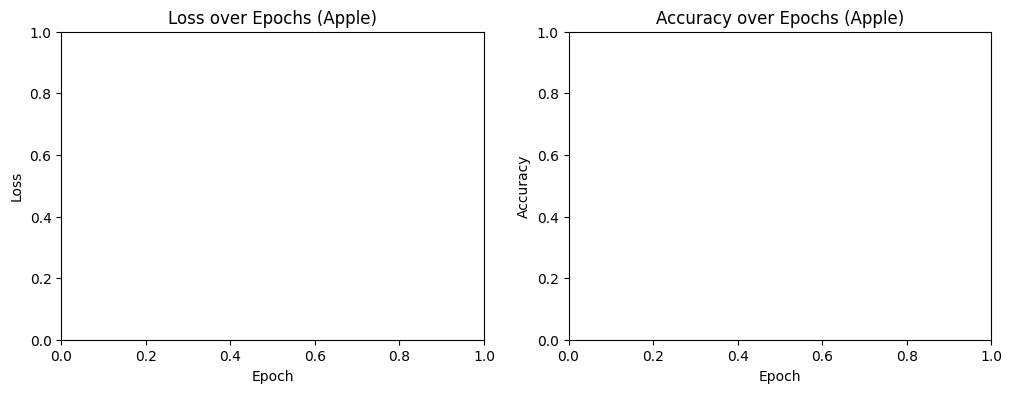

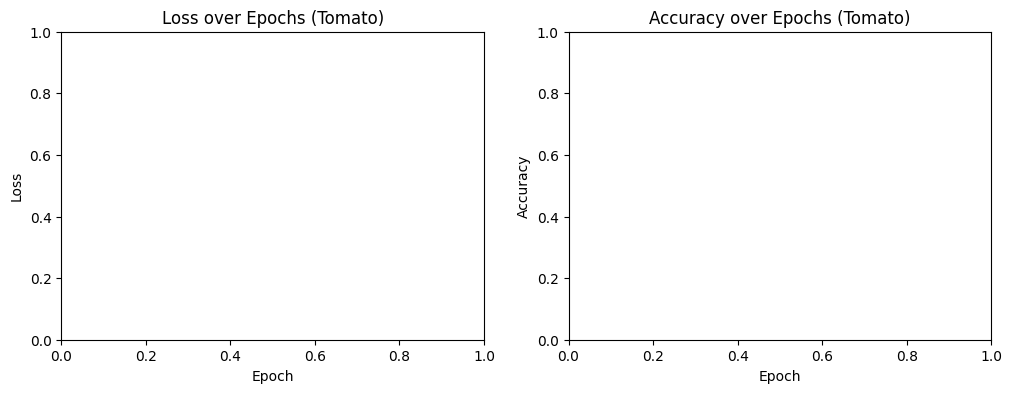

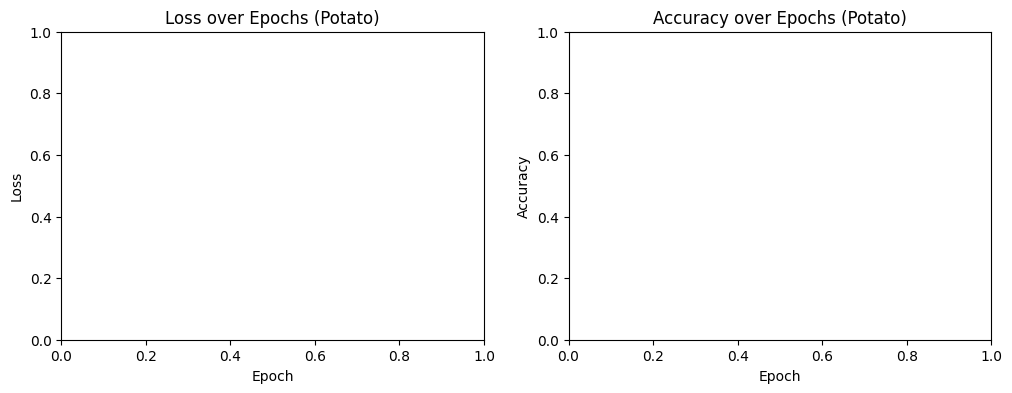

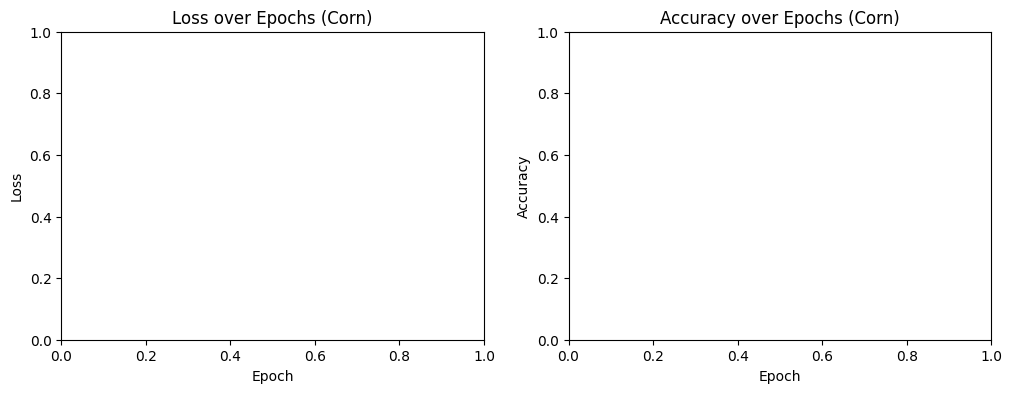

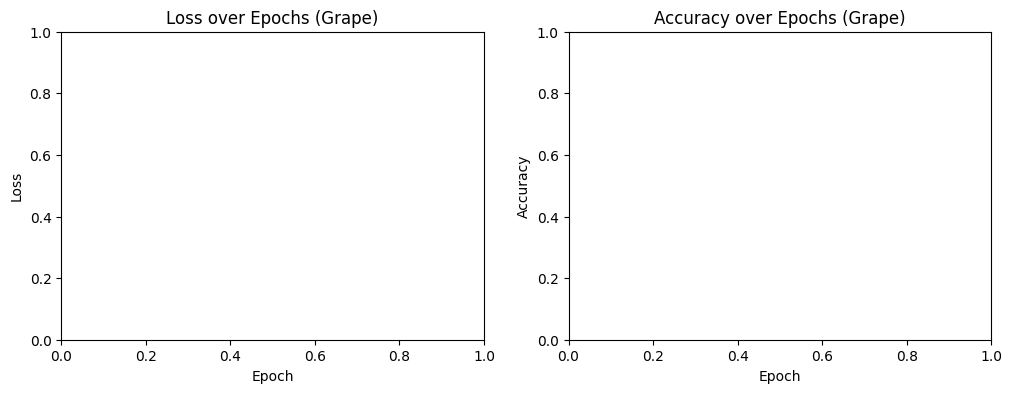

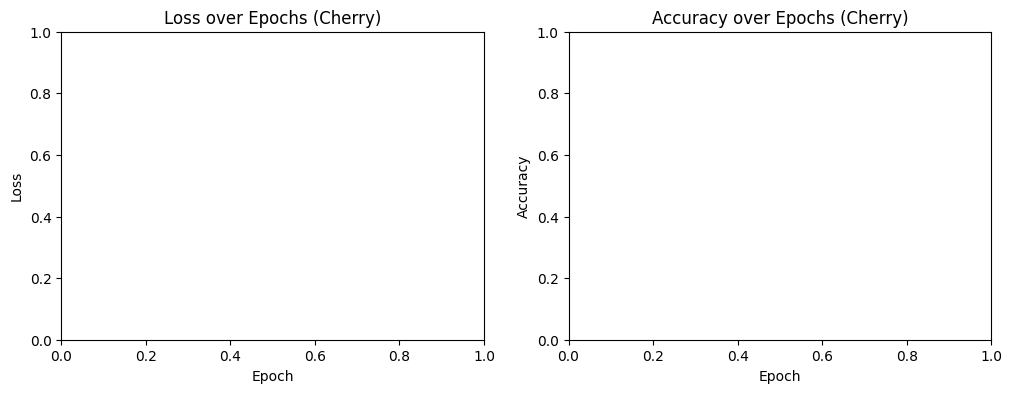

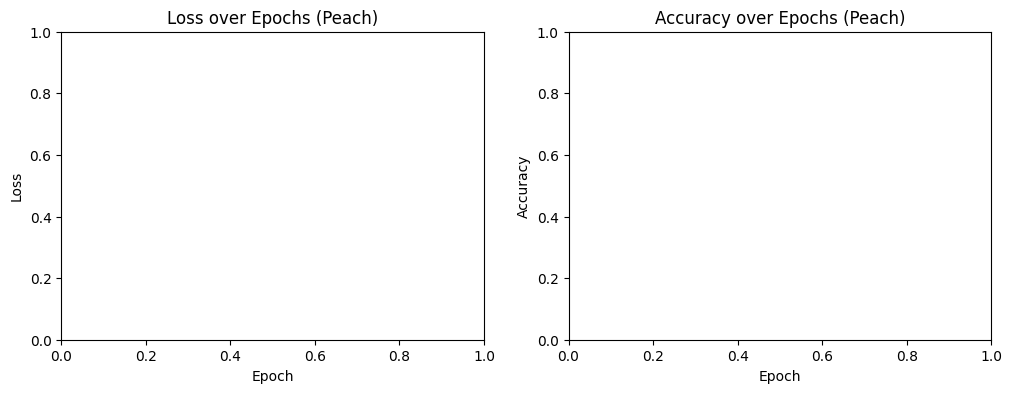

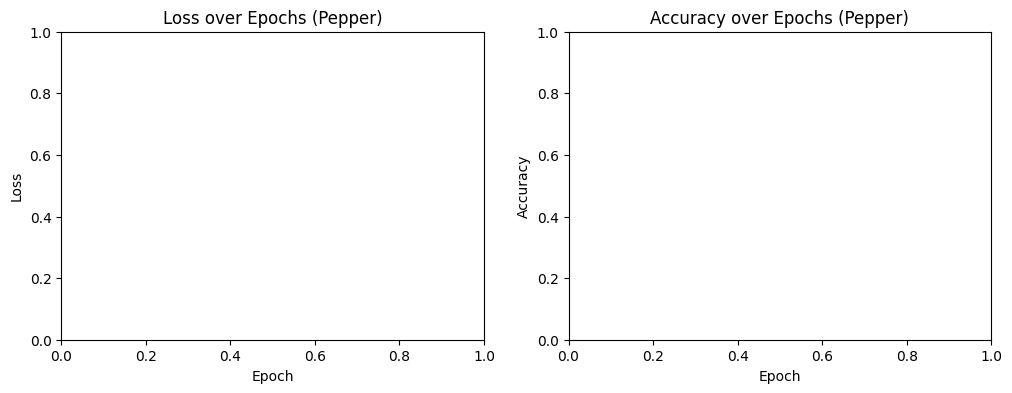

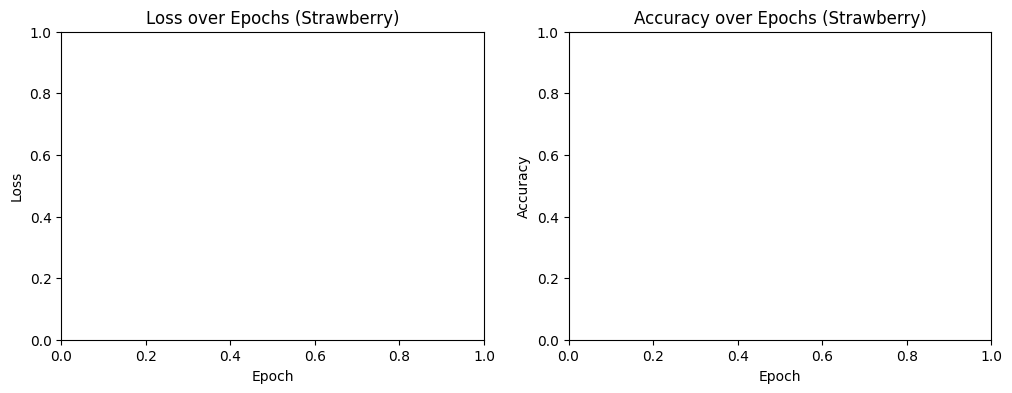

In [ ]:
# Cell 11: Huấn luyện ResNet50 cho từng loại cây (dùng cấu hình tập trung)
for plant_type in GROUPS.keys():
    print(f"\n=== Huấn luyện ResNet50 cho {plant_type} ===")
    model_path = f'{MODELS_DIR}/resnet50/final/{plant_type.lower()}_model.pth'
    best_model_path = f'{MODELS_DIR}/resnet50/best/{plant_type.lower()}_model.pth'
    checkpoint_path = f'{CHECKPOINTS_DIR}/resnet50/{plant_type.lower()}_checkpoint.pth'

    plant_df = df[df['plant_type'] == plant_type]
    if len(plant_df) == 0:
        print(f"Không có dữ liệu cho {plant_type}. Tạo file placeholder.")
        with open(model_path, 'w') as f:
            f.write(f"No model trained for {plant_type} due to insufficient data.")
        with open(best_model_path, 'w') as f:
            f.write(f"No best model trained for {plant_type} due to insufficient data.")
        continue

    train_df = plant_df[plant_df['dataset_type'] == 'train']
    val_df = plant_df[plant_df['dataset_type'] == 'valid']
    print(f"Số ảnh train ({plant_type}): {len(train_df)}")
    print(f"Số ảnh validation ({plant_type}): {len(val_df)}")

    if train_df.empty or val_df.empty:
        print(f"Lỗi: Tập train hoặc validation rỗng cho {plant_type}. Tạo file placeholder.")
        with open(model_path, 'w') as f:
            f.write(f"No model trained for {plant_type} due to empty train or validation set.")
        with open(best_model_path, 'w') as f:
            f.write(f"No best model trained for {plant_type} due to empty train or validation set.")
        continue

    class_names = GROUPS[plant_type]
    num_classes = len(class_names)
    print(f"Số lớp bệnh cho {plant_type}: {num_classes}")

    if num_classes <= 1:
        print(f"{plant_type} chỉ có 1 lớp ({class_names[0]}). Tạo file placeholder.")
        with open(model_path, 'w') as f:
            f.write(f"No model trained for {plant_type}. Single class: {class_names[0]}")
        with open(best_model_path, 'w') as f:
            f.write(f"No best model trained for {plant_type}. Single class: {class_names[0]}")
        continue

    train_image_paths = [os.path.join(media_root, row['image']) for _, row in train_df.iterrows()]
    train_labels = [class_names.index(row['disease']) for _, row in train_df.iterrows()]
    val_image_paths = [os.path.join(media_root, row['image']) for _, row in val_df.iterrows()]
    val_labels = [class_names.index(row['disease']) for _, row in val_df.iterrows()]

    train_dataset = PlantDiseaseDataset(train_image_paths, train_labels, transform=data_transforms['train'])
    val_dataset = PlantDiseaseDataset(val_image_paths, val_labels, transform=data_transforms['val'])
    train_dataset = Subset(train_dataset, train_dataset.valid_indices)
    val_dataset = Subset(val_dataset, val_dataset.valid_indices)

    # Dùng BATCH_SIZE từ cấu hình (giữ nguyên 32)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, drop_last=False)
    print(f"Số batch train ({plant_type}): {len(train_loader)}")
    print(f"Số batch validation ({plant_type}): {len(val_loader)}")

    # Khởi tạo ResNet50 (pretrained on ImageNet V2 - tốt hơn V1)
    model = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    model = model.to(device)

    # Adam optimizer với weight decay
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=ADAM_LR, weight_decay=ADAM_WEIGHT_DECAY)
    print(f"ResNet50 + Adam (LR={ADAM_LR}, Weight Decay={ADAM_WEIGHT_DECAY})")

    # Dùng NUM_EPOCHS và PATIENCE từ cấu hình, truyền model_name='resnet50'
    model, history = train_model(model, criterion, optimizer, train_loader, val_loader, 
                                 num_epochs=NUM_EPOCHS, patience=PATIENCE, device=device,
                                 model_path=model_path, best_model_path=best_model_path, 
                                 checkpoint_path=checkpoint_path, plant_type=plant_type, 
                                 model_name='resnet50', verbose=1)
    print(f"✓ ResNet50 hoàn tất: {model_path}")

if __name__ == "__main__":
    pass


# Huấn luyện MobileNetV2 cho tất cả các loại cây

Dưới đây là code huấn luyện MobileNetV2 cho từng loại cây để so sánh với ResNet50

In [ ]:
# Cell 13: Huấn luyện MobileNetV2 cho từng loại cây (dùng cấu hình tập trung)
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights

for plant_type in GROUPS.keys():
    print(f"\n=== Huấn luyện MobileNetV2 cho {plant_type} ===")
    model_path = f'{MODELS_DIR}/mobilenetv2/final/{plant_type.lower()}_model.pth'
    best_model_path = f'{MODELS_DIR}/mobilenetv2/best/{plant_type.lower()}_model.pth'
    checkpoint_path = f'{CHECKPOINTS_DIR}/mobilenetv2/{plant_type.lower()}_checkpoint.pth'

    plant_df = df[df['plant_type'] == plant_type]
    if len(plant_df) == 0:
        print(f"Không có dữ liệu cho {plant_type}. Tạo file placeholder.")
        with open(model_path, 'w') as f:
            f.write(f"No MobileNetV2 model trained for {plant_type} due to insufficient data.")
        with open(best_model_path, 'w') as f:
            f.write(f"No best MobileNetV2 model trained for {plant_type} due to insufficient data.")
        continue

    train_df = plant_df[plant_df['dataset_type'] == 'train']
    val_df = plant_df[plant_df['dataset_type'] == 'valid']
    print(f"Số ảnh train ({plant_type}): {len(train_df)}")
    print(f"Số ảnh validation ({plant_type}): {len(val_df)}")

    if train_df.empty or val_df.empty:
        print(f"Lỗi: Tập train hoặc validation rỗng cho {plant_type}. Tạo file placeholder.")
        with open(model_path, 'w') as f:
            f.write(f"No MobileNetV2 model trained for {plant_type} due to empty train or validation set.")
        with open(best_model_path, 'w') as f:
            f.write(f"No best MobileNetV2 model trained for {plant_type} due to empty train or validation set.")
        continue

    class_names = GROUPS[plant_type]
    num_classes = len(class_names)
    print(f"Số lớp bệnh cho {plant_type}: {num_classes}")

    if num_classes <= 1:
        print(f"{plant_type} chỉ có 1 lớp ({class_names[0]}). Tạo file placeholder.")
        with open(model_path, 'w') as f:
            f.write(f"No MobileNetV2 model trained for {plant_type}. Single class: {class_names[0]}")
        with open(best_model_path, 'w') as f:
            f.write(f"No best MobileNetV2 model trained for {plant_type}. Single class: {class_names[0]}")
        continue

    train_image_paths = [os.path.join(media_root, row['image']) for _, row in train_df.iterrows()]
    train_labels = [class_names.index(row['disease']) for _, row in train_df.iterrows()]
    val_image_paths = [os.path.join(media_root, row['image']) for _, row in val_df.iterrows()]
    val_labels = [class_names.index(row['disease']) for _, row in val_df.iterrows()]

    train_dataset = PlantDiseaseDataset(train_image_paths, train_labels, transform=data_transforms['train'])
    val_dataset = PlantDiseaseDataset(val_image_paths, val_labels, transform=data_transforms['val'])
    train_dataset = Subset(train_dataset, train_dataset.valid_indices)
    val_dataset = Subset(val_dataset, val_dataset.valid_indices)

    # Dùng BATCH_SIZE từ cấu hình
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, drop_last=False)
    print(f"Số batch train ({plant_type}): {len(train_loader)}")
    print(f"Số batch validation ({plant_type}): {len(val_loader)}")

    # Khởi tạo MobileNetV2
    model = mobilenet_v2(weights=MobileNet_V2_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    model = model.to(device)

    # Adam optimizer với weight decay
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.classifier.parameters(), lr=ADAM_LR, weight_decay=ADAM_WEIGHT_DECAY)
    print(f"MobileNetV2 + Adam (LR={ADAM_LR}, Weight Decay={ADAM_WEIGHT_DECAY})")

    # Dùng NUM_EPOCHS và PATIENCE từ cấu hình, truyền model_name='mobilenetv2'
    # verbose=1: chỉ in thông tin mỗi epoch (không có progress bar) → giảm lag
    model, history = train_model(model, criterion, optimizer, train_loader, val_loader, 
                                 num_epochs=NUM_EPOCHS, patience=PATIENCE, device=device,
                                 model_path=model_path, best_model_path=best_model_path, 
                                 checkpoint_path=checkpoint_path, plant_type=plant_type, 
                                 model_name='mobilenetv2', verbose=1)
    print(f"✓ MobileNetV2 hoàn tất: {model_path}")

# Huấn luyện EfficientNet-B0 cho tất cả các loại cây

Dưới đây là code huấn luyện EfficientNet-B0 cho từng loại cây để so sánh

In [ ]:
# Cell 15: Huấn luyện EfficientNet-B0 cho từng loại cây (dùng transforms + LR riêng)
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

for plant_type in GROUPS.keys():
    print(f"\n=== Huấn luyện EfficientNet-B0 cho {plant_type} ===")
    model_path = f'{MODELS_DIR}/efficientnetb0/final/{plant_type.lower()}_model.pth'
    best_model_path = f'{MODELS_DIR}/efficientnetb0/best/{plant_type.lower()}_model.pth'
    checkpoint_path = f'{CHECKPOINTS_DIR}/efficientnetb0/{plant_type.lower()}_checkpoint.pth'

    plant_df = df[df['plant_type'] == plant_type]
    if len(plant_df) == 0:
        print(f"Không có dữ liệu cho {plant_type}. Tạo file placeholder.")
        with open(model_path, 'w') as f:
            f.write(f"No EfficientNet-B0 model trained for {plant_type} due to insufficient data.")
        with open(best_model_path, 'w') as f:
            f.write(f"No best EfficientNet-B0 model trained for {plant_type} due to insufficient data.")
        continue

    train_df = plant_df[plant_df['dataset_type'] == 'train']
    val_df = plant_df[plant_df['dataset_type'] == 'valid']
    print(f"Số ảnh train ({plant_type}): {len(train_df)}")
    print(f"Số ảnh validation ({plant_type}): {len(val_df)}")

    if train_df.empty or val_df.empty:
        print(f"Lỗi: Tập train hoặc validation rỗng cho {plant_type}. Tạo file placeholder.")
        with open(model_path, 'w') as f:
            f.write(f"No EfficientNet-B0 model trained for {plant_type} due to empty train or validation set.")
        with open(best_model_path, 'w') as f:
            f.write(f"No best EfficientNet-B0 model trained for {plant_type} due to empty train or validation set.")
        continue

    class_names = GROUPS[plant_type]
    num_classes = len(class_names)
    print(f"Số lớp bệnh cho {plant_type}: {num_classes}")

    if num_classes <= 1:
        print(f"{plant_type} chỉ có 1 lớp ({class_names[0]}). Tạo file placeholder.")
        with open(model_path, 'w') as f:
            f.write(f"No EfficientNet-B0 model trained for {plant_type}. Single class: {class_names[0]}")
        with open(best_model_path, 'w') as f:
            f.write(f"No best EfficientNet-B0 model trained for {plant_type}. Single class: {class_names[0]}")
        continue

    train_image_paths = [os.path.join(media_root, row['image']) for _, row in train_df.iterrows()]
    train_labels = [class_names.index(row['disease']) for _, row in train_df.iterrows()]
    val_image_paths = [os.path.join(media_root, row['image']) for _, row in val_df.iterrows()]
    val_labels = [class_names.index(row['disease']) for _, row in val_df.iterrows()]

    # Dùng efficientnet_transforms (tối ưu cho EfficientNet-B0)
    train_dataset = PlantDiseaseDataset(train_image_paths, train_labels, transform=efficientnet_transforms['train'])
    val_dataset = PlantDiseaseDataset(val_image_paths, val_labels, transform=efficientnet_transforms['val'])
    train_dataset = Subset(train_dataset, train_dataset.valid_indices)
    val_dataset = Subset(val_dataset, val_dataset.valid_indices)

    # Dùng BATCH_SIZE từ cấu hình
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, drop_last=False)
    print(f"Số batch train ({plant_type}): {len(train_loader)}")
    print(f"Số batch validation ({plant_type}): {len(val_loader)}")

    # Khởi tạo EfficientNet-B0 (V1 - PyTorch chỉ có V1)
    model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
    for param in model.parameters():
        param.requires_grad = False
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    model = model.to(device)

    # Adam optimizer với LR thấp hơn và weight decay
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.classifier.parameters(), lr=ADAM_LR_EFFICIENTNET, weight_decay=ADAM_WEIGHT_DECAY)
    print(f"EfficientNet-B0 + Adam (LR={ADAM_LR_EFFICIENTNET}, Weight Decay={ADAM_WEIGHT_DECAY})")

    # Dùng NUM_EPOCHS và PATIENCE từ cấu hình
    model, history = train_model(model, criterion, optimizer, train_loader, val_loader, 
                                 num_epochs=NUM_EPOCHS, patience=PATIENCE, device=device,
                                 model_path=model_path, best_model_path=best_model_path, 
                                 checkpoint_path=checkpoint_path, plant_type=plant_type, 
                                 model_name='efficientnetb0', verbose=1)
    print(f"✓ EfficientNet-B0 hoàn tất: {model_path}")


In [ ]:
# Cell 16: So sánh kết quả 3 models cho tất cả plant types
import pandas as pd

print("\n=== SO SÁNH KẾT QUẢ 3 MODELS (Tất cả Plant Types) ===\n")

# Tạo dictionary để lưu kết quả từng plant_type cho mỗi model
resnet_results = {}
mobilenet_results = {}
efficientnet_results = {}

# Đọc kết quả từ các checkpoint hoặc training logs (giả sử đã lưu trong quá trình huấn luyện)
# Nếu không có, có thể tạo placeholder để điền sau khi huấn luyện xong
for plant_type in GROUPS.keys():
    resnet_checkpoint = f'{CHECKPOINTS_DIR}/resnet50/{plant_type.lower()}_checkpoint.pth'
    mobilenet_checkpoint = f'{CHECKPOINTS_DIR}/mobilenetv2/{plant_type.lower()}_checkpoint.pth'
    efficientnet_checkpoint = f'{CHECKPOINTS_DIR}/efficientnetb0/{plant_type.lower()}_checkpoint.pth'
    
    # Đọc val_accs từ checkpoint (nếu tồn tại)
    if os.path.exists(resnet_checkpoint):
        try:
            checkpoint = torch.load(resnet_checkpoint, map_location=device)
            resnet_results[plant_type] = max(checkpoint['val_accs']) if checkpoint['val_accs'] else 0.0
        except:
            resnet_results[plant_type] = 0.0
    else:
        resnet_results[plant_type] = 0.0
    
    if os.path.exists(mobilenet_checkpoint):
        try:
            checkpoint = torch.load(mobilenet_checkpoint, map_location=device)
            mobilenet_results[plant_type] = max(checkpoint['val_accs']) if checkpoint['val_accs'] else 0.0
        except:
            mobilenet_results[plant_type] = 0.0
    else:
        mobilenet_results[plant_type] = 0.0
    
    if os.path.exists(efficientnet_checkpoint):
        try:
            checkpoint = torch.load(efficientnet_checkpoint, map_location=device)
            efficientnet_results[plant_type] = max(checkpoint['val_accs']) if checkpoint['val_accs'] else 0.0
        except:
            efficientnet_results[plant_type] = 0.0
    else:
        efficientnet_results[plant_type] = 0.0

# Tạo DataFrame so sánh
comparison_data = {
    'Plant Type': list(GROUPS.keys()),
    'ResNet50+Adam': [resnet_results[pt] for pt in GROUPS.keys()],
    'MobileNetV2+Adam': [mobilenet_results[pt] for pt in GROUPS.keys()],
    'EfficientNet-B0+Adam': [efficientnet_results[pt] for pt in GROUPS.keys()]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

# Tính trung bình accuracy của từng model
avg_resnet = comparison_df['ResNet50+Adam'].mean()
avg_mobilenet = comparison_df['MobileNetV2+Adam'].mean()
avg_efficientnet = comparison_df['EfficientNet-B0+Adam'].mean()

print(f"\n=== TRUNG BÌNH ACCURACY (Adam Optimizer) ===")
print(f"ResNet50+Adam: {avg_resnet:.4f}")
print(f"MobileNetV2+Adam: {avg_mobilenet:.4f}")
print(f"EfficientNet-B0+Adam: {avg_efficientnet:.4f}")

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ cột so sánh từng plant type
x = range(len(GROUPS.keys()))
width = 0.25
axes[0].bar([i - width for i in x], comparison_df['ResNet50+Adam'], width, label='ResNet50+Adam', alpha=0.8)
axes[0].bar(x, comparison_df['MobileNetV2+Adam'], width, label='MobileNetV2+Adam', alpha=0.8)
axes[0].bar([i + width for i in x], comparison_df['EfficientNet-B0+Adam'], width, label='EfficientNet-B0+Adam', alpha=0.8)
axes[0].set_xlabel('Plant Type')
axes[0].set_ylabel('Best Validation Accuracy')
axes[0].set_title('Model Comparison (Adam Optimizer)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(GROUPS.keys(), rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Biểu đồ cột so sánh trung bình
models = ['ResNet50+Adam', 'MobileNetV2+Adam', 'EfficientNet-B0+Adam']
avg_accs = [avg_resnet, avg_mobilenet, avg_efficientnet]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
axes[1].bar(models, avg_accs, color=colors, alpha=0.8)
axes[1].set_ylabel('Average Validation Accuracy')
axes[1].set_title('Average Performance (Adam Optimizer)')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(avg_accs):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()

# Lưu vào thư mục comparison
comparison_dir = f'{PLOTS_DIR}/comparison'
os.makedirs(comparison_dir, exist_ok=True)
comparison_plot_path = f'{comparison_dir}/disease_model_comparison_adam.png'
plt.savefig(comparison_plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Biểu đồ so sánh Adam: {comparison_plot_path}")
print(f"\n=== TỔNG KẾT ADAM ===")
print(f"Optimizer: Adam (with weight decay)")
print(f"LR: ResNet50/MobileNetV2={ADAM_LR}, EfficientNet-B0={ADAM_LR_EFFICIENTNET}")
print(f"Weight Decay: {ADAM_WEIGHT_DECAY}")
print(f"Models lưu tại: {MODELS_DIR}")
